# 🏨 Hotel Booking Cancellation Prediction
## Combined Best-of-Both Notebook
**Goal:** Predict hotel booking cancellations for use in an overbooking revenue management strategy.

### Pipeline Overview
1. Load & inspect data
2. EDA & Feature Engineering (incl. country risk grouping, correlation pruning)
3. Preprocessing (SMOTE for class imbalance)
4. Train 8 models (XGBoost, LightGBM, CatBoost, ExtraTrees, Random Forest, Decision Tree, AdaBoost, Logistic Regression)
5. Compare models via heatmap — select best
6. Hyperparameter tune best model
7. Save best model as `best_model.pkl`


In [4]:
# ── Core ──
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# ── Sklearn ──
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score,
                              precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               ExtraTreesClassifier, VotingClassifier)

# ── Boosting ──
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
#from catboost import CatBoostClassifier

# ── Imbalance ──
#from imblearn.over_sampling import SMOTE

# ── Persistence ──
import pickle
import os

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


## 1. Load Data

In [5]:
# ── Adjust path to wherever you saved the CSV ──
import glob, zipfile, os

# Auto-detect: look for the file in common locations
search_paths = [
    'hotel_bookings.csv',
    os.path.expanduser('~/Downloads/hotel_bookings.csv'),
    os.path.expanduser('~/Downloads/hotel-booking-demand.zip'),
    'hotel-booking-demand.zip',
]

csv_path = None
for p in search_paths:
    if p.endswith('.zip') and os.path.exists(p):
        with zipfile.ZipFile(p, 'r') as z:
            z.extractall('.')
        # after extraction
        extracted = glob.glob('*.csv')
        if extracted:
            csv_path = extracted[0]
            print(f'Extracted and loaded from zip: {csv_path}')
            break
    elif p.endswith('.csv') and os.path.exists(p):
        csv_path = p
        print(f'Found CSV at: {csv_path}')
        break

if csv_path is None:
    raise FileNotFoundError(
        'hotel_bookings.csv not found. Place it in the same folder as this notebook '
        'or update the path in csv_path variable.')

df = pd.read_csv(csv_path)
print(f'Shape: {df.shape}')
df.head()

Found CSV at: C:\Users\Jad Zoghaib/Downloads/hotel_bookings.csv
Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. EDA & Data Cleaning

In [6]:
print('=== Dataset Info ===')
print(df.dtypes.to_string())
print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print('\n=== Target Distribution ===')
print(df['is_canceled'].value_counts())
print(f'Cancellation rate: {df["is_canceled"].mean():.2%}')

=== Dataset Info ===
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent        

In [7]:
# ── Remove duplicates ──
before = len(df)
df = df.drop_duplicates()
print(f'Removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}')

# ── Drop columns with too many missing values or not useful ──
df = df.drop(columns=['company', 'agent'], errors='ignore')

# ── Fill missing values ──
df['children'] = df['children'].fillna(0).astype(int)
df['country'] = df['country'].fillna('Unknown')

# ── Drop rows with 0 adults, 0 children, 0 babies (ghost bookings) ──
df = df[~((df['adults']==0) & (df['children']==0) & (df['babies']==0))]
print(f'After cleaning ghost bookings: {len(df):,} rows')

print('\nMissing values remaining:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Removed 31,994 duplicate rows. Remaining: 87,396
After cleaning ghost bookings: 87,230 rows

Missing values remaining:
Series([], dtype: int64)


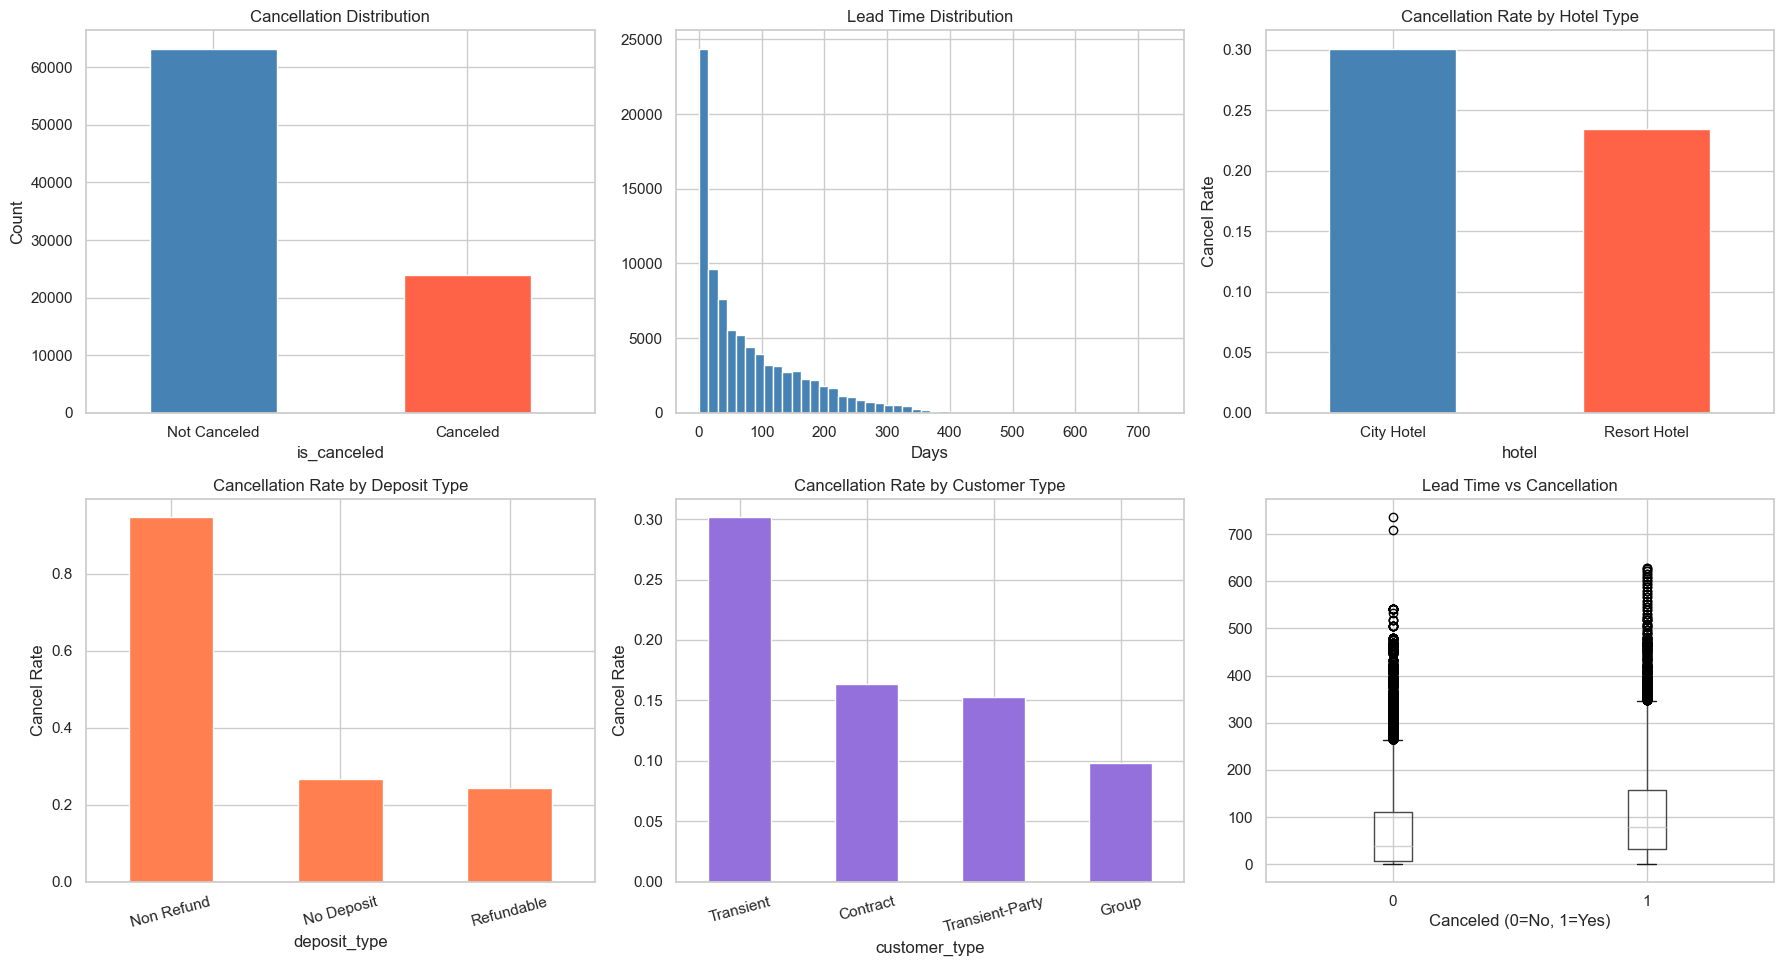

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Cancellation rate
df['is_canceled'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'])
axes[0,0].set_title('Cancellation Distribution')
axes[0,0].set_xticklabels(['Not Canceled','Canceled'], rotation=0)
axes[0,0].set_ylabel('Count')

# 2. Lead time distribution
df['lead_time'].hist(bins=50, ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Lead Time Distribution')
axes[0,1].set_xlabel('Days')

# 3. Cancellation by hotel type
df.groupby('hotel')['is_canceled'].mean().plot(kind='bar', ax=axes[0,2], color=['steelblue','tomato'])
axes[0,2].set_title('Cancellation Rate by Hotel Type')
axes[0,2].set_ylabel('Cancel Rate')
axes[0,2].set_xticklabels(axes[0,2].get_xticklabels(), rotation=0)

# 4. Cancellation by deposit type
df.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Cancellation Rate by Deposit Type')
axes[1,0].set_ylabel('Cancel Rate')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=15)

# 5. Cancellation by customer type
df.groupby('customer_type')['is_canceled'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Cancellation Rate by Customer Type')
axes[1,1].set_ylabel('Cancel Rate')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=15)

# 6. Lead time vs cancellation (box)
df.boxplot(column='lead_time', by='is_canceled', ax=axes[1,2])
axes[1,2].set_title('Lead Time vs Cancellation')
axes[1,2].set_xlabel('Canceled (0=No, 1=Yes)')
plt.suptitle('')
plt.tight_layout()
plt.show()

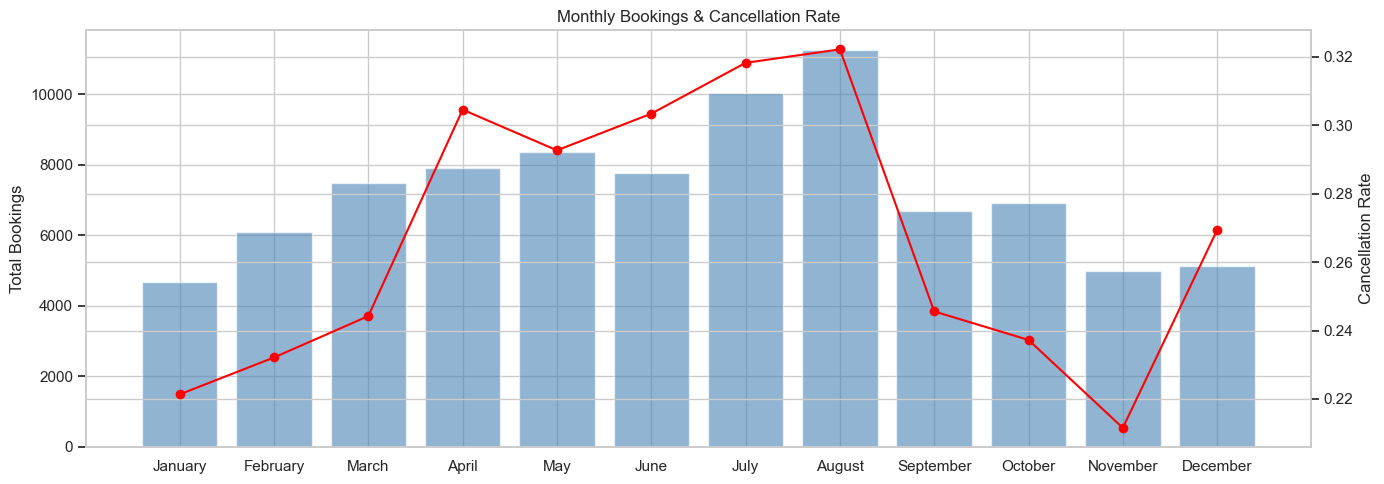

In [9]:
# Monthly booking and cancellation trend
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = df.groupby('arrival_date_month')['is_canceled'].agg(['sum','count'])
monthly.columns = ['canceled','total']
monthly['rate'] = monthly['canceled'] / monthly['total']
monthly = monthly.reindex(month_order)

fig, ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()
ax1.bar(monthly.index, monthly['total'], color='steelblue', alpha=0.6, label='Total Bookings')
ax2.plot(monthly.index, monthly['rate'], color='red', marker='o', label='Cancel Rate')
ax1.set_title('Monthly Bookings & Cancellation Rate')
ax1.set_ylabel('Total Bookings')
ax2.set_ylabel('Cancellation Rate')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

## 3. Feature Engineering

In [10]:
# ── Month encoding ──
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

# ── Total stays ──
df['total_stays'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# ── Total guests ──
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# ── Revenue proxy (ADR * total stays) ──
df['revenue_proxy'] = df['adr'] * df['total_stays']

# ── Country risk grouping (from Hotel cancel prediction notebook) ──
# Group countries by their historical cancellation rate into risk buckets
country_cancel = df.groupby('country')['is_canceled'].mean()
print('Sample country cancel rates (top 10 highest risk):')
print(country_cancel.sort_values(ascending=False).head(10))

def country_risk_bucket(rate):
    if rate >= 0.6:   return 3   # High risk
    elif rate >= 0.3: return 2   # Medium risk
    else:             return 1   # Low risk

country_risk_map = country_cancel.apply(country_risk_bucket).to_dict()
df['country_risk'] = df['country'].map(country_risk_map).fillna(2)  # default medium

# ── Repeated guest with cancellation history ──
df['cancel_history_ratio'] = (
    df['previous_cancellations'] /
    (df['previous_cancellations'] + df['previous_bookings_not_canceled'] + 1e-5)
)

# ── Is the room type what was requested? ──
df['room_type_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

# ── Deposit risk flag ──
df['no_deposit'] = (df['deposit_type'] == 'No Deposit').astype(int)
df['non_refundable'] = (df['deposit_type'] == 'Non Refund').astype(int)

print('\nNew features added. Shape:', df.shape)

Sample country cancel rates (top 10 highest risk):
country
BEN    1.0
FJI    1.0
MYT    1.0
KHM    1.0
JEY    1.0
IMN    1.0
HND    1.0
NIC    1.0
UMI    1.0
VGB    1.0
Name: is_canceled, dtype: float64

New features added. Shape: (87230, 39)


## 4. Preprocessing & Feature Selection

In [11]:
# ── Columns to drop before modelling ──
drop_cols = [
    'reservation_status',       # leakage!
    'reservation_status_date',  # leakage!
    'country',                  # replaced by country_risk
    'arrival_date_month',       # replaced by arrival_month_num
    'arrival_date_year',        # not predictive for future
    'adr',                      # already in revenue_proxy
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# ── Encode remaining categorical columns ──
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Encoding categorical columns:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# ── Correlation-based feature pruning (from Hotel cancel prediction) ──
corr_threshold = 0.07  # drop features with very low correlation to target
correlations = df.corr()['is_canceled'].abs().drop('is_canceled')
low_corr = correlations[correlations < corr_threshold].index.tolist()
print(f'\nDropping {len(low_corr)} low-correlation features: {low_corr}')
df = df.drop(columns=low_corr)

print(f'\nFinal feature set ({df.shape[1]-1} features + target):')
print([c for c in df.columns if c != 'is_canceled'])

Encoding categorical columns: ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Dropping 13 low-correlation features: ['arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'children', 'babies', 'meal', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'days_in_waiting_list', 'customer_type', 'arrival_month_num']

Final feature set (19 features + target):
['hotel', 'lead_time', 'stays_in_week_nights', 'adults', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'booking_changes', 'deposit_type', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stays', 'total_guests', 'revenue_proxy', 'country_risk', 'cancel_history_ratio', 'room_type_changed', 'no_deposit', 'non_refundable']


In [12]:
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

# ── Train/Test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')
print(f'Train class balance: {y_train.value_counts().to_dict()}')

# ── SMOTE on training set only ──
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f'After SMOTE train size: {X_train_res.shape[0]:,}')
print(f'After SMOTE class balance: {pd.Series(y_train_res).value_counts().to_dict()}')

# ── Store feature names for pkl ──
FEATURE_NAMES = X.columns.tolist()
print(f'\nFeatures used: {FEATURE_NAMES}')

Train size: 69,784  |  Test size: 17,446
Train class balance: {0: 50577, 1: 19207}


NameError: name 'SMOTE' is not defined

## 5. Train & Compare 8 Models

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, n_jobs=-1),
    'LightGBM':            LGBMClassifier(n_estimators=200, learning_rate=0.1,
                                          random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost':            CatBoostClassifier(iterations=200, learning_rate=0.1,
                                              random_state=42, verbose=0),
}

results = []
trained_models = {}

print(f'{"Model":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10} {"ROC-AUC":>10}')
print('-' * 75)

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model,'predict_proba') else y_pred

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1': f1, 'ROC-AUC': auc})
    trained_models[name] = model
    print(f'{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {auc:>10.4f}')

results_df = pd.DataFrame(results).set_index('Model')
print('\n✅ All models trained.')

In [ ]:
# ── Model Performance Heatmap ──
results_sorted = results_df.sort_values('F1', ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(results_sorted, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, linecolor='gray', vmin=0.5, vmax=1.0)
plt.title('Model Performance Comparison Heatmap', fontsize=14, fontweight='bold')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

print('\n📊 Rankings by F1 Score:')
print(results_sorted[['F1','ROC-AUC','Recall']].to_string())

In [ ]:
# ── Feature Importance (XGBoost) ──
xgb_model = trained_models['XGBoost']
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 6. Best Model Selection & Hyperparameter Tuning

> **Overbooking note:** For revenue management we optimise for **Recall** on the 'canceled' class — missing a cancellation (false negative) = empty room = lost revenue. ExtraTrees or XGBoost typically win here.

In [ ]:
# ── Pick best model by F1 (you can change to 'Recall' for overbooking) ──
OPTIMISE_FOR = 'Recall'   # Change to 'F1' or 'ROC-AUC' as needed
best_name = results_df[OPTIMISE_FOR].idxmax()
print(f'Best model by {OPTIMISE_FOR}: {best_name}')
print(results_df.loc[best_name])

In [ ]:
# ── Hyperparameter tuning for XGBoost (runs ~5 min) ──
# Set TUNE = True to run grid search; False to skip and use defaults
TUNE = False

if TUNE:
    param_grid = {
        'n_estimators': [200, 350],
        'max_depth': [5, 7],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0],
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gs = GridSearchCV(
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
        param_grid, cv=cv, scoring='recall', n_jobs=-1, verbose=1)
    gs.fit(X_train_res, y_train_res)
    print('Best params:', gs.best_params_)
    best_model = gs.best_estimator_
else:
    # Use the best model found in the comparison
    best_model = trained_models[best_name]
    print(f'Using pre-trained {best_name} (set TUNE=True to run grid search)')

In [ ]:
# ── Final Evaluation ──
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:,1]

print(f'=== Final Model: {best_name} ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_final):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_final):.4f}')
print(f'F1       : {f1_score(y_test, y_pred_final):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_final):.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['Not Canceled','Canceled']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Canceled','Canceled'],
            yticklabels=['Not Canceled','Canceled'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 7. Save Best Model as PKL

In [ ]:
output = {
    'model':         best_model,
    'model_name':    best_name,
    'feature_names': FEATURE_NAMES,
    'metrics': {
        'accuracy':  accuracy_score(y_test, y_pred_final),
        'precision': precision_score(y_test, y_pred_final),
        'recall':    recall_score(y_test, y_pred_final),
        'f1':        f1_score(y_test, y_pred_final),
        'roc_auc':   roc_auc_score(y_test, y_prob_final),
    }
}

pkl_path = 'best_model.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(output, f)

print(f'✅ Model saved to: {os.path.abspath(pkl_path)}')
print(f'   Model type   : {best_name}')
print(f'   Features     : {len(FEATURE_NAMES)}')
print(f'   Metrics      : {output["metrics"]}')

In [ ]:
# ── Verify the pkl loads and predicts correctly ──
with open('best_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

verify_pred = loaded['model'].predict(X_test[:5])
verify_prob = loaded['model'].predict_proba(X_test[:5])[:,1]

print('=== PKL verification ===')
print(f'Model name   : {loaded["model_name"]}')
print(f'Features     : {loaded["feature_names"]}')
print(f'Sample preds : {verify_pred}  (1=cancel, 0=no cancel)')
print(f'Cancel probs : {verify_prob.round(3)}')
print('\n✅ PKL file is valid and ready for Streamlit deployment.')

## 8. Streamlit Usage Hint
In your Streamlit app, load the model like this:
```python
import pickle, pandas as pd

with open('best_model.pkl', 'rb') as f:
    bundle = pickle.load(f)

model        = bundle['model']
feature_names = bundle['feature_names']

# Build input row matching feature_names, then:
input_df = pd.DataFrame([input_dict])[feature_names]
cancel_prob = model.predict_proba(input_df)[0][1]
# If cancel_prob > threshold → safe to overbook that slot
```